# **Configuración experimental**
Para realizar este paso en la metodología de validación, se utilizará una partición de datos usando un 80% para los datos de entrenamiento y 20% para los datos de prueba, además se garantizará que los hiperparámetros seleccionados sean óptimos y se evitará el sobreajuste, aplicando la validación cruzada (Cross Validation) en el conjunto de entrenamiento.
Adicionalmente, en el tratamiento de valores no disponibles (NA), se adjudica por mediana para las variables numéricas como la altitud y la moda para las variables categóricas.

# **Carga del Dataset**

In [34]:
#CARGA DEL DATASET

# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "arabica_data_cleaned.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "volpatto/coffee-quality-database-from-cqi",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

#print("First 5 records:", df.head())

#Validar datos
#print(df.to_string())

#Filas - Columnas
n_muestras = df.shape[0]
n_caracteristicas = df.shape[1]

#print(df.columns)



Using Colab cache for faster access to the 'coffee-quality-database-from-cqi' dataset.


In [35]:
print("Número de muestras:", n_muestras)
print("Número de características:", n_caracteristicas)

Número de muestras: 1311
Número de características: 44


# **Preparación de los Datos**

In [36]:
#import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Estandarización de nombres (Solución al KeyError)
df.columns = [c.replace(' ', '.') for c in df.columns]

# 2. Selección de variables (Asegúrate de que los puntos coincidan)
features_num = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body',
                'Balance', 'Uniformity', 'Clean.Cup', 'Sweetness', 'Moisture']
target = 'Total.Cup.Points'

# 3. Manejo de valores nulos (Imputación por mediana)
for col in features_num:
    df[col] = df[col].fillna(df[col].median())

# 4. Definición de X y y
X = df[features_num]
y = df[target]

# 5. División del dataset (Hold-out 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Escalado de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos listos para entrenamiento. Columnas seleccionadas con éxito.")

Datos listos para entrenamiento. Columnas seleccionadas con éxito.


# **Regresión Lineal**

In [37]:
#Paramétrico	Regresión Lineal

from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

def modelo_parametrico(eta=0.01, iteraciones=1000, verbose=False):
  """Modelo paramétrico para usar la regresión lineal
    eta: Taza de aprendizaje
    iteraciones: Número de iteraciones a realizar
  """
  # Configuración del modelo: Regresión Lineal mediante Gradiente Descendente Estocástico
  # Usamos 'squared_error' para Regresión Lineal tradicional
  regresion = SGDRegressor(
      loss='squared_error',
      #penalty='l2',          # Regularización Ridge para evitar sobreajuste
      #alpha=0.0001,          # Fuerza de la regularización
      learning_rate='constant',
      eta0=eta,             # Tasa de aprendizaje inicial
      max_iter=iteraciones,
      random_state=42
  )

  # Entrenamiento
  regresion.fit(X_train_scaled, y_train)

  # Predicción y Evaluación
  y_pred_param = regresion.predict(X_test_scaled)
  mse_param = mean_squared_error(y_test, y_pred_param)
  rmse_param = np.sqrt(mse_param)
  r2_param = r2_score(y_test, y_pred_param)

  if verbose:
    print("--- Modelo Paramétrico (Regresión Lineal SGD) ---")
    print(f"RMSE: {rmse_param:.4f}")
    print(f"R2 Score: {r2_param:.4f}")

  return y_pred_param

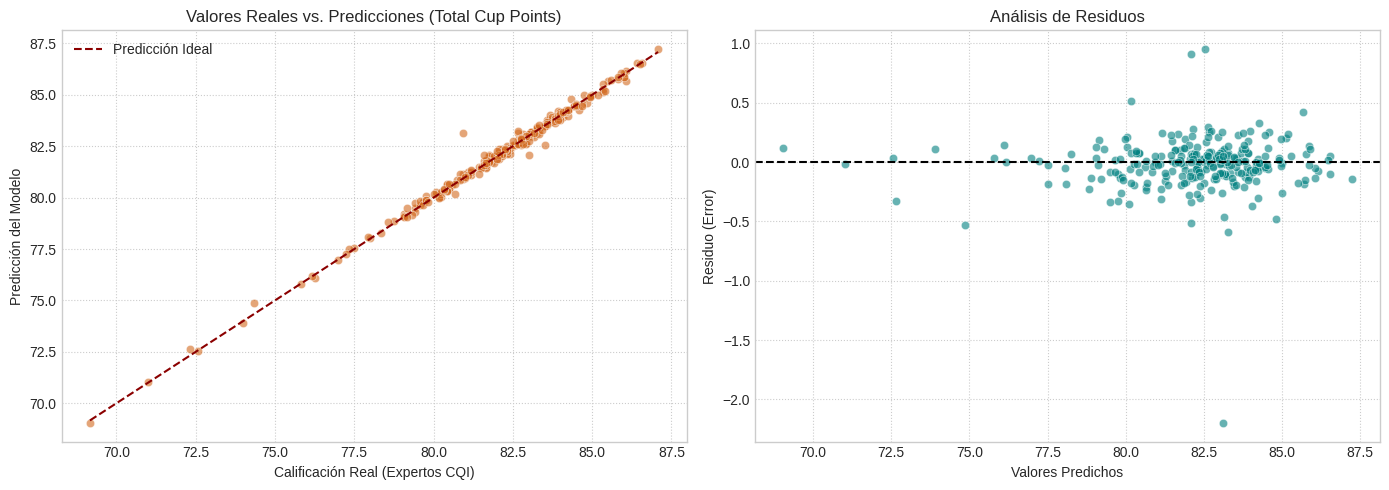

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ejecutar el modelo y obtener resultados
y_pred_param = modelo_parametrico(eta=0.001, iteraciones=1000)

# 2. Configurar el lienzo de las gráficas (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- GRÁFICA 1: Valores Reales vs. Predicciones ---
sns.scatterplot(x=y_test, y=y_pred_param, alpha=0.6, ax=axes[0], color='chocolate')
# Línea de referencia ideal (Donde predicción = real)
lims = [max(min(y_test), min(y_pred_param)), min(max(y_test), max(y_pred_param))]
axes[0].plot(lims, lims, color='darkred', linestyle='--', label='Predicción Ideal')

axes[0].set_title('Valores Reales vs. Predicciones (Total Cup Points)', fontsize=12)
axes[0].set_xlabel('Calificación Real (Expertos CQI)', fontsize=10)
axes[0].set_ylabel('Predicción del Modelo', fontsize=10)
axes[0].grid(True, linestyle=':')
axes[0].legend()

# --- GRÁFICA 2: Análisis de Residuos (Errores) ---
residuos = y_test - y_pred_param
sns.scatterplot(x=y_pred_param, y=residuos, alpha=0.6, ax=axes[1], color='teal')
axes[1].axhline(y=0, color='black', linestyle='--') # Línea base cero

axes[1].set_title('Análisis de Residuos', fontsize=12)
axes[1].set_xlabel('Valores Predichos', fontsize=10)
axes[1].set_ylabel('Residuo (Error)', fontsize=10)
axes[1].grid(True, linestyle=':')

# Ajustar y mostrar
plt.tight_layout()
plt.show()

In [39]:
_=modelo_parametrico(verbose=True)

--- Modelo Paramétrico (Regresión Lineal SGD) ---
RMSE: 0.3300
R2 Score: 0.9826


# **K-Nearest Neighbors (KNN)**

In [40]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def modelo_no_parametrico(k=5, verbose=False):
  """Modelo no paramétrico para usar KNN
    k: Número de vecinos
  """
  # Configuración del modelo No Paramétrico (KNN para Regresión)
  # Evaluaremos k=5 como base, usando la distancia Euclídea estándar
  modelo_knn = KNeighborsRegressor(
      n_neighbors=k,
      weights='uniform', # Todos los vecinos vecinos aportan por igual
      metric='minkowski',
      p=2                # p=2 equivale a la distancia Euclídea
  )

  # Entrenamiento (KNN almacena los vectores en memoria)
  modelo_knn.fit(X_train_scaled, y_train)

  # Predicción y Evaluación
  y_pred_knn = modelo_knn.predict(X_test_scaled)
  mse_knn = mean_squared_error(y_test, y_pred_knn)
  rmse_knn = np.sqrt(mse_knn)
  r2_knn = r2_score(y_test, y_pred_knn)

  if verbose:
    print(f"--- Modelo No Paramétrico (KNN Regressor) con k={k} ---")
    print(f"RMSE: {rmse_knn:.4f}")
    print(f"R2 Score: {r2_knn:.4f}")

  return rmse_knn, r2_knn, y_pred_knn

In [41]:
_ = modelo_no_parametrico(5,True)

--- Modelo No Paramétrico (KNN Regressor) con k=5 ---
RMSE: 0.6040
R2 Score: 0.9416


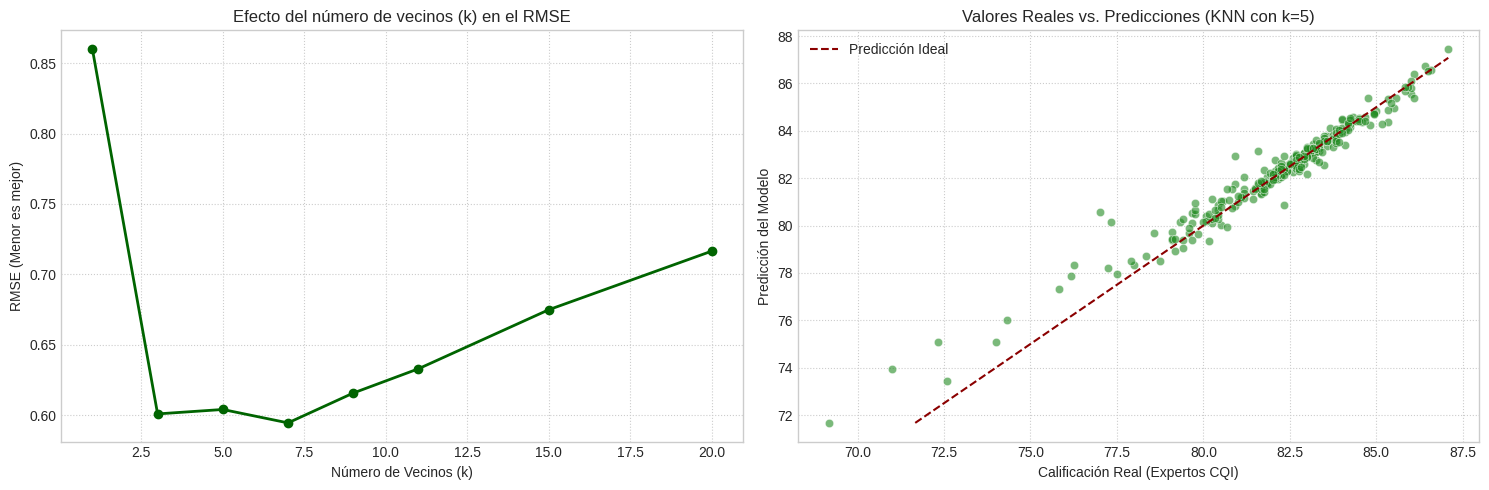

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- PARTE 1: Gráfica de Optimización de K (Curva de Error) ---
valores_k = [1, 3, 5, 7, 9, 11, 15, 20]
lista_rmse = []
lista_r2 = []

for k in valores_k:
    rmse, r2, _ = modelo_no_parametrico(k=k)
    lista_rmse.append(rmse)
    lista_r2.append(r2)

# Crear el lienzo para las visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica de codo (RMSE vs K)
axes[0].plot(valores_k, lista_rmse, marker='o', linestyle='-', color='darkgreen', linewidth=2)
axes[0].set_title('Efecto del número de vecinos (k) en el RMSE', fontsize=12)
axes[0].set_xlabel('Número de Vecinos (k)', fontsize=10)
axes[0].set_ylabel('RMSE (Menor es mejor)', fontsize=10)
axes[0].grid(True, linestyle=':')

# --- PARTE 2: Predicciones del modelo óptimo (ejemplo k=5) ---
# Ejecutamos una vez más con tu valor base para graficar su dispersión
_, _, y_pred_optimo = modelo_no_parametrico(k=5)

sns.scatterplot(x=y_test, y=y_pred_optimo, alpha=0.6, ax=axes[1], color='forestgreen')
lims = [max(min(y_test), min(y_pred_optimo)), min(max(y_test), max(y_pred_optimo))]
axes[1].plot(lims, lims, color='darkred', linestyle='--', label='Predicción Ideal')

axes[1].set_title('Valores Reales vs. Predicciones (KNN con k=5)', fontsize=12)
axes[1].set_xlabel('Calificación Real (Expertos CQI)', fontsize=10)
axes[1].set_ylabel('Predicción del Modelo', fontsize=10)
axes[1].grid(True, linestyle=':')
axes[1].legend()

plt.tight_layout()
plt.show()

# **Random Forest**

In [43]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def modelo_random_forest(num_trees=100, muestras_min=2, verbose=False):
  """Modelo no paramétrico para usar KNN
    k: Número de vecinos
    num_trees: Número de árboles
    muestras_min: Número mínimo de muestras
  """
  # Configuración del modelo de Ensamble (Random Forest)
  modelo_rf = RandomForestRegressor(
      n_estimators=num_trees,     # Número de árboles en el bosque
      max_depth=10,         # Profundidad máxima de los árboles para evitar sobreajuste
      min_samples_split=muestras_min,  # Mínimo de muestras requeridas para dividir un nodo interno
      random_state=42       # Semilla para asegurar la reproducibilidad en GitHub
  )

  # Entrenamiento del modelo
  modelo_rf.fit(X_train_scaled, y_train)

  # Predicción y Evaluación
  y_pred_rf = modelo_rf.predict(X_test_scaled)
  mse_rf = mean_squared_error(y_test, y_pred_rf)
  rmse_rf = np.sqrt(mse_rf)
  r2_rf = r2_score(y_test, y_pred_rf)

  if verbose:
    print(f"--- Modelo de Ensamble (Random Forest Regressor) ---")
    print(f"RMSE: {rmse_rf:.4f}")
    print(f"R2 Score: {r2_rf:.4f}")

  return modelo_rf, y_pred_rf

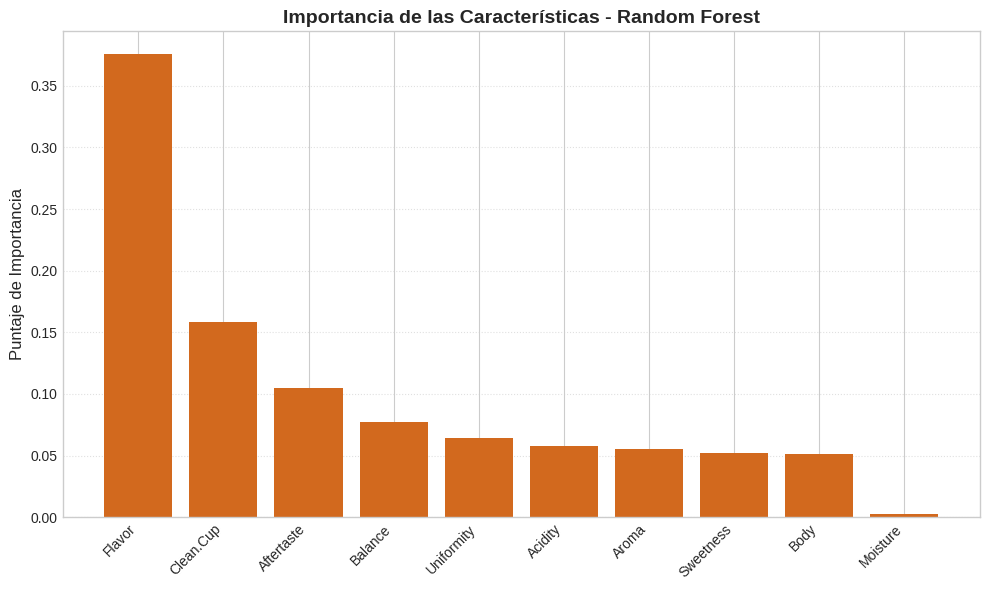

In [44]:
import matplotlib.pyplot as plt

# 1. Ejecutamos la función y guardamos el modelo entrenado en 'rf_entrenado'
rf_entrenado, y_pred_rf = modelo_random_forest(num_trees=100, muestras_min=2)

# 2. Tu código de graficación adaptado (ahora usa 'rf_entrenado')
importancias = rf_entrenado.feature_importances_
indices = np.argsort(importancias)[::-1]

# Asegúrate de que 'features_num' esté definido globalmente con los nombres de tus columnas
nombres_features = [features_num[i] for i in indices]

# Graficar
plt.figure(figsize=(10, 6))
plt.title("Importancia de las Características - Random Forest", fontsize=14, fontweight='bold')
plt.bar(range(X.shape[1]), importancias[indices], align="center", color="chocolate")
plt.xticks(range(X.shape[1]), nombres_features, rotation=45, ha='right')
plt.ylabel("Puntaje de Importancia", fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# **MLP Regressor**

In [45]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import warnings
from sklearn.exceptions import ConvergenceWarning

# Filtra y oculta específicamente los avisos de convergencia
warnings.filterwarnings("ignore", category=ConvergenceWarning)

def modelo_MLP_Regressor(capas=50, neuronas=25, verbose=False):
  """Modelo no paramétrico para usar KNN
    k: Número de vecinos
    num_trees: Número de árboles
  """
  # Configuración de la Red Neuronal Artificial (Perceptrón Multicapa)
  # Diseñamos una arquitectura con dos capas ocultas (de 50 y 25 neuronas respectivamente)
  modelo_mlp = MLPRegressor(
      hidden_layer_sizes=(capas, neuronas), # Arquitectura de las capas ocultas
      activation='relu',           # Función de activación no lineal
      solver='adam',               # Algoritmo de optimización basado en gradiente estocástico
      alpha=0.001,                 # Parámetro de regularización L2
      batch_size='auto',
      learning_rate_init=0.01,     # Tasa de aprendizaje inicial (eta)
      max_iter=500,                # Máximo de iteraciones (épocas de entrenamiento)
      random_state=42              # Semilla de reproducibilidad para GitHub
  )

  # Entrenamiento de la red neuronal
  modelo_mlp.fit(X_train_scaled, y_train)

  # Predicción y Evaluación
  y_pred_mlp = modelo_mlp.predict(X_test_scaled)
  mse_mlp = mean_squared_error(y_test, y_pred_mlp)
  rmse_mlp = np.sqrt(mse_mlp)
  r2_mlp = r2_score(y_test, y_pred_mlp)

  if verbose:
    print(f"--- Red Neuronal Artificial (MLP Regressor) ---")
    print(f"RMSE: {rmse_mlp:.4f}")
    print(f"R2 Score: {r2_mlp:.4f}")

  return modelo_mlp

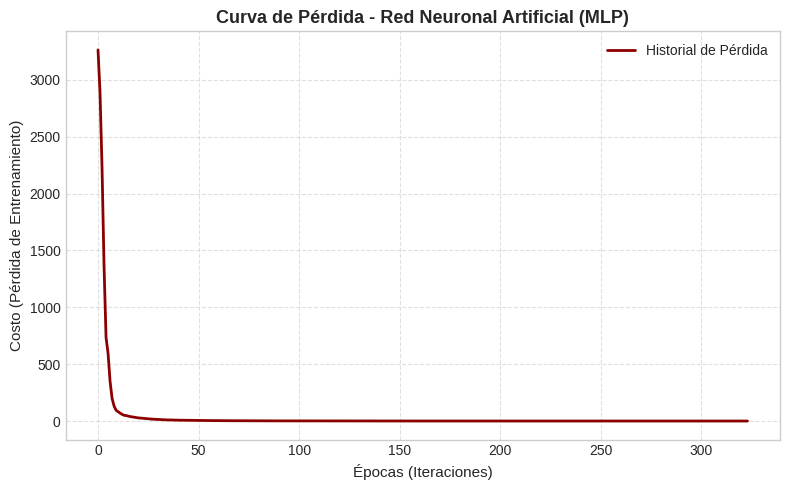

In [46]:
import matplotlib.pyplot as plt

# 1. Ejecutamos la función y guardamos el modelo entrenado
mlp_entrenado = modelo_MLP_Regressor(capas=50, neuronas=25)

# 2. Código de graficación corregido (ahora usa 'mlp_entrenado')
plt.figure(figsize=(8, 5))
plt.plot(mlp_entrenado.loss_curve_, color='darkred', lw=2, label='Historial de Pérdida')
plt.title('Curva de Pérdida - Red Neuronal Artificial (MLP)', fontsize=13, fontweight='bold')
plt.xlabel('Épocas (Iteraciones)', fontsize=11)
plt.ylabel('Costo (Pérdida de Entrenamiento)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# **Máquinas de Vectores de Soporte - SVR**

In [47]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


def modelo_support_vector(kernel='rbf', gamma='scale', verbose=False):
  """Modelo no paramétrico para usar KNN
    k: Número de vecinos
    num_trees: Número de árboles
  """
  # Configuración de la Máquina de Vectores de Soporte para Regresión (SVR)
  # Usamos el Kernel 'rbf' (Radial Basis Function) para mapear interacciones complejas
  modelo_svr = SVR(
      kernel=kernel,
      C=1.0,            # Parámetro de regularización (balance entre margen y error)
      epsilon=0.1,      # Ancho del tubo de tolerancia donde no se penaliza el error
      gamma=gamma     # Coeficiente del kernel para controlar la influencia de las muestras
  )

  # Entrenamiento del modelo
  modelo_svr.fit(X_train_scaled, y_train)

  # Predicción y Evaluación
  y_pred_svr = modelo_svr.predict(X_test_scaled)
  mse_svr = mean_squared_error(y_test, y_pred_svr)
  rmse_svr = np.sqrt(mse_svr)
  r2_svr = r2_score(y_test, y_pred_svr)

  if verbose:
    print(f"--- Máquina de Vectores de Soporte (Support Vector Regressor) ---")
    print(f"RMSE: {rmse_svr:.4f}")
    print(f"R2 Score: {r2_svr:.4f}")

  return y_pred_svr

In [48]:
print('***Kernel lineal***')
_=modelo_support_vector(kernel='linear', verbose=True)
print('\n***Kernel rbf***')
_=modelo_support_vector(kernel='rbf', verbose=True)

***Kernel lineal***
--- Máquina de Vectores de Soporte (Support Vector Regressor) ---
RMSE: 0.2233
R2 Score: 0.9920

***Kernel rbf***
--- Máquina de Vectores de Soporte (Support Vector Regressor) ---
RMSE: 0.8419
R2 Score: 0.8866


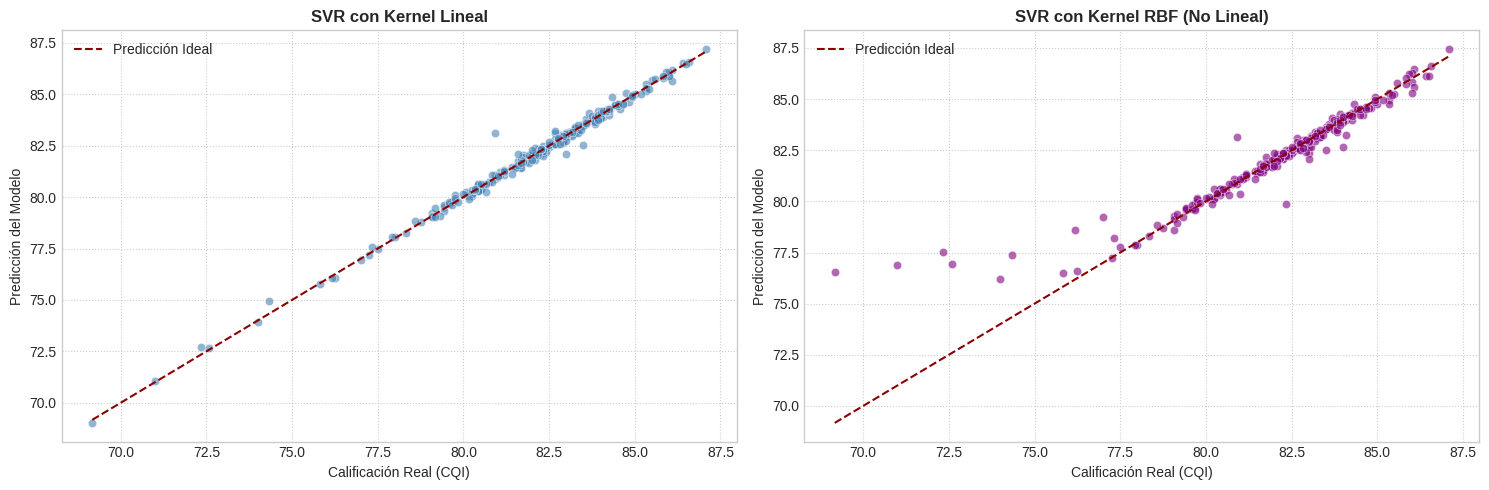

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Obtenemos las predicciones para dos configuraciones distintas de la malla
y_pred_linear = modelo_support_vector(kernel='linear')
y_pred_rbf = modelo_support_vector(kernel='rbf')

# 2. Configurar el lienzo (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Línea ideal común para ambas gráficas
lims = [min(y_test), max(y_test)]

# --- SUBGRÁFICA 1: SVR Kernel Lineal ---
sns.scatterplot(x=y_test, y=y_pred_linear, alpha=0.6, ax=axes[0], color='steelblue')
axes[0].plot(lims, lims, color='darkred', linestyle='--', label='Predicción Ideal')
axes[0].set_title('SVR con Kernel Lineal', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Calificación Real (CQI)', fontsize=10)
axes[0].set_ylabel('Predicción del Modelo', fontsize=10)
axes[0].grid(True, linestyle=':')
axes[0].legend()

# --- SUBGRÁFICA 2: SVR Kernel RBF (No Lineal) ---
sns.scatterplot(x=y_test, y=y_pred_rbf, alpha=0.6, ax=axes[1], color='purple')
axes[1].plot(lims, lims, color='darkred', linestyle='--', label='Predicción Ideal')
axes[1].set_title('SVR con Kernel RBF (No Lineal)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Calificación Real (CQI)', fontsize=10)
axes[1].set_ylabel('Predicción del Modelo', fontsize=10)
axes[1].grid(True, linestyle=':')
axes[1].legend()

plt.tight_layout()
plt.show()

In [50]:
#Paramétrico	Regresión Lineal
#No Paramétrico	K-Nearest Neighbors (KNN)
#Ensamble	Random Forest
#Red Neuronal	MLP Regressor
#Vectores de Soporte	SVM

# **Resultados**

In [51]:
_=modelo_parametrico(verbose=True)
_=modelo_no_parametrico(verbose=True)
_=modelo_random_forest(verbose=True)
_=modelo_MLP_Regressor(verbose=True)
_=modelo_support_vector(verbose=True)

--- Modelo Paramétrico (Regresión Lineal SGD) ---
RMSE: 0.3300
R2 Score: 0.9826
--- Modelo No Paramétrico (KNN Regressor) con k=5 ---
RMSE: 0.6040
R2 Score: 0.9416
--- Modelo de Ensamble (Random Forest Regressor) ---
RMSE: 0.6341
R2 Score: 0.9357
--- Red Neuronal Artificial (MLP Regressor) ---
RMSE: 0.7019
R2 Score: 0.9212
--- Máquina de Vectores de Soporte (Support Vector Regressor) ---
RMSE: 0.8419
R2 Score: 0.8866


# **TABLA MAESTRA DE DESEMPEÑO**

In [52]:
import pandas as pd
import numpy as np
import time
from sklearn.metrics import mean_squared_error, r2_score

# Diccionario para almacenar la nueva estructura de datos
resultados_completos = {}

print("Iniciando simulación global con métricas de Training, Testing y Tiempos...\n")

# --- 1. REGRESIÓN LINEAL (SGD) ---
# Instanciamos el modelo para medirlo desde el inicio
from sklearn.linear_model import SGDRegressor
modelo_sgd = SGDRegressor(loss='squared_error', learning_rate='constant', eta0=0.01, max_iter=1000, random_state=42)

inicio = time.time()
modelo_sgd.fit(X_train_scaled, y_train)
y_pred_train_sgd = modelo_sgd.predict(X_train_scaled)
y_pred_test_sgd = modelo_sgd.predict(X_test_scaled)
fin = time.time()
tiempo_sgd = fin - inicio

resultados_completos['1. Regresión Lineal (SGD)'] = {
    'Train MSE': mean_squared_error(y_train, y_pred_train_sgd),
    'Test MSE': mean_squared_error(y_test, y_pred_test_sgd),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train_sgd)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test_sgd)),
    'Train R2': r2_score(y_train, y_pred_train_sgd),
    'Test R2': r2_score(y_test, y_pred_test_sgd),
    'Tiempo (seg)': tiempo_sgd
}

# --- 2. K-NEAREST NEIGHBORS ---
from sklearn.neighbors import KNeighborsRegressor
modelo_knn = KNeighborsRegressor(n_neighbors=5, weights='uniform', metric='minkowski', p=2)

inicio = time.time()
modelo_knn.fit(X_train_scaled, y_train)
y_pred_train_knn = modelo_knn.predict(X_train_scaled)
y_pred_test_knn = modelo_knn.predict(X_test_scaled)
fin = time.time()
tiempo_knn = fin - inicio

resultados_completos['2. K-Nearest Neighbors'] = {
    'Train MSE': mean_squared_error(y_train, y_pred_train_knn),
    'Test MSE': mean_squared_error(y_test, y_pred_test_knn),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train_knn)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test_knn)),
    'Train R2': r2_score(y_train, y_pred_train_knn),
    'Test R2': r2_score(y_test, y_pred_test_knn),
    'Tiempo (seg)': tiempo_knn
}

# --- 3. RANDOM FOREST ---
from sklearn.ensemble import RandomForestRegressor
modelo_rf = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_split=2, random_state=42)

inicio = time.time()
modelo_rf.fit(X_train_scaled, y_train)
y_pred_train_rf = modelo_rf.predict(X_train_scaled)
y_pred_test_rf = modelo_rf.predict(X_test_scaled)
fin = time.time()
tiempo_rf = fin - inicio

resultados_completos['3. Random Forest'] = {
    'Train MSE': mean_squared_error(y_train, y_pred_train_rf),
    'Test MSE': mean_squared_error(y_test, y_pred_test_rf),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train_rf)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test_rf)),
    'Train R2': r2_score(y_train, y_pred_train_rf),
    'Test R2': r2_score(y_test, y_pred_test_rf),
    'Tiempo (seg)': tiempo_rf
}

# --- 4. PERCEPTRÓN MULTICAPA (MLP) ---
from sklearn.neural_network import MLPRegressor
modelo_mlp = MLPRegressor(hidden_layer_sizes=(50, 25), activation='relu', solver='adam', alpha=0.001, max_iter=500, random_state=42)

inicio = time.time()
modelo_mlp.fit(X_train_scaled, y_train)
y_pred_train_mlp = modelo_mlp.predict(X_train_scaled)
y_pred_test_mlp = modelo_mlp.predict(X_test_scaled)
fin = time.time()
tiempo_mlp = fin - inicio

resultados_completos['4. Perceptrón Multicapa'] = {
    'Train MSE': mean_squared_error(y_train, y_pred_train_mlp),
    'Test MSE': mean_squared_error(y_test, y_pred_test_mlp),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train_mlp)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test_mlp)),
    'Train R2': r2_score(y_train, y_pred_train_mlp),
    'Test R2': r2_score(y_test, y_pred_test_mlp),
    'Tiempo (seg)': tiempo_mlp
}

# --- 5. VECTORES DE SOPORTE (SVR) ---
from sklearn.svm import SVR
modelo_svr = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')

inicio = time.time()
modelo_svr.fit(X_train_scaled, y_train)
y_pred_train_svr = modelo_svr.predict(X_train_scaled)
y_pred_test_svr = modelo_svr.predict(X_test_scaled)
fin = time.time()
tiempo_svr = fin - inicio

resultados_completos['5. Support Vector Regressor'] = {
    'Train MSE': mean_squared_error(y_train, y_pred_train_svr),
    'Test MSE': mean_squared_error(y_test, y_pred_test_svr),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train_svr)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test_svr)),
    'Train R2': r2_score(y_train, y_pred_train_svr),
    'Test R2': r2_score(y_test, y_pred_test_svr),
    'Tiempo (seg)': tiempo_svr
}

# 2. Convertir a DataFrame y ordenar por Test R2
df_master = pd.DataFrame(resultados_completos).T
df_master = df_master.sort_values(by='Test R2', ascending=False)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\n--- TABLA MAESTRA DE DESEMPEÑO (TRAIN VS TEST) ---")
print(df_master.round(5))

Iniciando simulación global con métricas de Training, Testing y Tiempos...


--- TABLA MAESTRA DE DESEMPEÑO (TRAIN VS TEST) ---
                             Train MSE  Test MSE  Train RMSE  Test RMSE  Train R2  Test R2  Tiempo (seg)
1. Regresión Lineal (SGD)      0.15084   0.10890     0.38838    0.33000   0.98913  0.98258       0.00844
2. K-Nearest Neighbors         2.90859   0.36481     1.70546    0.60399   0.79047  0.94165       0.03950
3. Random Forest               0.73073   0.40210     0.85483    0.63411   0.94736  0.93568       0.53554
5. Support Vector Regressor    7.12883   0.70883     2.66999    0.84192   0.48644  0.88662       0.14304
4. Perceptrón Multicapa        0.70672   2.33810     0.84067    1.52909   0.94909  0.62600       3.73633


# **GRÁFICA COMPARATIVA DE LA TABLA MAESTRA DE DESEMPEÑO**

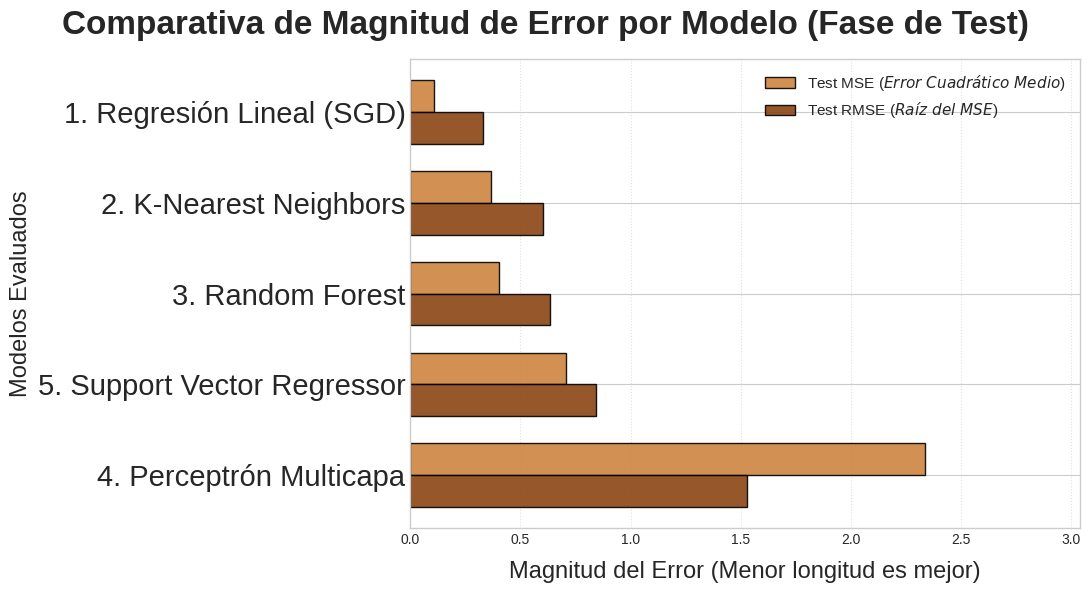

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuración del estilo visual científico
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# 2. Invertimos el orden de los datos para que el mejor modelo aparezca arriba en el eje Y
df_invertido = df_master.iloc[::-1]

modelos = df_invertido.index
test_mse = df_invertido['Test MSE']
test_rmse = df_invertido['Test RMSE']

# Configuración de posiciones en el eje Y (para barras horizontales)
y = np.arange(len(modelos))
height = 0.35  # Grosor de las barras horizontales

# Creamos el contenedor del gráfico
fig, ax = plt.subplots(figsize=(11, 6))

# 3. Dibujar las barras horizontales usando .barh()
barras_mse = ax.barh(y + height/2, test_mse, height, label=r'Test MSE ($Error\ Cuadrático\ Medio$)', color='peru', edgecolor='black', alpha=0.9)
barras_rmse = ax.barh(y - height/2, test_rmse, height, label=r'Test RMSE ($Raíz\ del\ MSE$)', color='saddlebrown', edgecolor='black', alpha=0.9)

# 4. Personalización de etiquetas y títulos (Estilo Transpuesto IEEE)
fig.suptitle('Comparativa de Magnitud de Error por Modelo (Fase de Test)',
             fontsize=24, fontweight='bold', x=0.5, ha='center', y=0.98)
ax.set_xlabel('Magnitud del Error (Menor longitud es mejor)', fontsize=17, labelpad=10)
ax.set_ylabel('Modelos Evaluados', fontsize=17)
ax.set_yticks(y)
ax.set_yticklabels(modelos, fontsize=21)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='x', linestyle=':', alpha=0.6)

# 5. Función automatizada para colocar el valor numérico al final de cada barra horizontal
"""def agregar_etiquetas_horizontales(barras):
    for barra in barras:
        ancho = barra.get_width()
        ax.annotate(f'{ancho:.4f}',
                    xy=(ancho, barra.get_y() + barra.get_height() / 2),
                    xytext=(3, 0),  # Desfase de 3 puntos horizontales hacia la derecha
                    textcoords="offset points",
                    ha='left', va='center', fontsize=9, fontweight='bold')

agregar_etiquetas_horizontales(barras_mse)
agregar_etiquetas_horizontales(barras_rmse)"""

# Ajustar los límites del eje X para dar espacio a las etiquetas de texto del final
ax.set_xlim(0, max(test_rmse.max(), test_mse.max()) * 1.30)

plt.tight_layout()

# 6. Guardar en alta definición para el documento final
plt.savefig('comparativa_errores_transpuesta.png', dpi=300)
plt.show()

# **FASE DE VALIDACIÓN CRUZADA E HIPERPARÁMETROS**

In [54]:
import numpy as np
import pandas as pd
import time
import warnings
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.exceptions import ConvergenceWarning

# Ocultar advertencias de convergencia para mantener la salida limpia y legible
warnings.filterwarnings("ignore", category=ConvergenceWarning)

print("================================================================================")
# El \u2615 representa el icono de una taza de café en la consola
print("    FASE DE VALIDACIÓN CRUZADA E HIPERPARÁMETROS - DATASET CQI ARÁBICA \u2615")
print("================================================================================")

def calcular_intervalo_confianza(scores):
    """Calcula la media, desviación estándar e intervalo de confianza al 95%"""
    media = np.mean(scores)
    sigma = np.std(scores)
    limite_inferior = media - (2 * sigma)
    limite_superior = media + (2 * sigma)
    intervalo_str = f"[{limite_inferior:.4f} a {limite_superior:.4f}]"
    return media, sigma, intervalo_str

# ================================================================================
# 1. MODELO PARAMÉTRICO: REGRESIÓN LINEAL (SGD)
# ================================================================================
print("\n[PROCESANDO] 1. Regresión Lineal (SGD) -> Evaluando Tasa de Aprendizaje Inicial (eta0)...")
resultados_sgd = []
tasas_aprendizaje = [0.001, 0.01, 0.1, 0.5]

for eta in tasas_aprendizaje:
    modelo = SGDRegressor(loss='squared_error', learning_rate='constant', eta0=eta, max_iter=1000, random_state=42)
    scores = cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring='r2')
    media, sigma, intervalo = calcular_intervalo_confianza(scores)

    resultados_sgd.append({
        'Hiperparámetro (eta0)': eta,
        'R2 Validación (Media)': media,
        'Desviación (σ)': sigma,
        'Intervalo de Confianza (95%)': intervalo
    })

df_sgd = pd.DataFrame(resultados_sgd)
print("\n--- TABLA DE VALIDACIÓN: REGRESIÓN LINEAL (SGD) ---")
print(df_sgd.to_string(index=False))
print("-" * 80)


# ================================================================================
# 2. MODELO NO PARAMÉTRICO: K-NEAREST NEIGHBORS (KNN)
# ================================================================================
print("\n[PROCESANDO] 2. K-Nearest Neighbors -> Evaluando Número de Vecinos (k)...")
resultados_knn = []
valores_k = [3, 5, 11, 21]

for k in valores_k:
    modelo = KNeighborsRegressor(n_neighbors=k, weights='uniform', metric='minkowski', p=2)
    scores = cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring='r2')
    media, sigma, intervalo = calcular_intervalo_confianza(scores)

    resultados_knn.append({
        'Hiperparámetro (k)': k,
        'R2 Validación (Media)': media,
        'Desviación (σ)': sigma,
        'Intervalo de Confianza (95%)': intervalo
    })

df_knn = pd.DataFrame(resultados_knn)
print("\n--- TABLA DE VALIDACIÓN: K-NEAREST NEIGHBORS (KNN) ---")
print(df_knn.to_string(index=False))
print("-" * 80)


# ================================================================================
# 3. ENSAMBLE DE ÁRBOLES: RANDOM FOREST
# ================================================================================
print("\n[PROCESANDO] 3. Random Forest -> Evaluando Profundidad Máxima (max_depth)...")
resultados_rf = []
profundidades = [3, 5, 10, 20]

for depth in profundidades:
    modelo = RandomForestRegressor(n_estimators=100, max_depth=depth, min_samples_split=2, random_state=42)
    scores = cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring='r2')
    media, sigma, intervalo = calcular_intervalo_confianza(scores)

    resultados_rf.append({
        'Hiperparámetro (max_depth)': depth,
        'R2 Validación (Media)': media,
        'Desviación (σ)': sigma,
        'Intervalo de Confianza (95%)': intervalo
    })

df_rf = pd.DataFrame(resultados_rf)
print("\n--- TABLA DE VALIDACIÓN: RANDOM FOREST ---")
print(df_rf.to_string(index=False))
print("-" * 80)


# ================================================================================
# 4. MÁQUINA DE VECTORES DE SOPORTE (SVR)
# ================================================================================
print("\n[PROCESANDO] 4. Support Vector Regressor -> Evaluando Penalización (C)...")
resultados_svr = []
valores_c = [0.1, 1.0, 10.0, 100.0]

for c in valores_c:
    modelo = SVR(kernel='rbf', C=c, epsilon=0.1, gamma='scale')
    scores = cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring='r2')
    media, sigma, intervalo = calcular_intervalo_confianza(scores)

    resultados_svr.append({
        'Hiperparámetro (C)': c,
        'R2 Validación (Media)': media,
        'Desviación (σ)': sigma,
        'Intervalo de Confianza (95%)': intervalo
    })

df_svr = pd.DataFrame(resultados_svr)
print("\n--- TABLA DE VALIDACIÓN: SUPPORT VECTOR REGRESSOR (SVR) ---")
print(df_svr.to_string(index=False))
print("-" * 80)


# ================================================================================
# 5. RED NEURONAL ARTIFICIAL: PERCEPTRÓN MULTICAPA (MLP)
# ================================================================================
print("\n[PROCESANDO] 5. Perceptrón Multicapa -> Evaluando Arquitectura (Capas Ocultas)...")
resultados_mlp = []
arquitecturas = [(10,), (50, 25), (100, 50, 25)]

for arq in arquitecturas:
    modelo = MLPRegressor(hidden_layer_sizes=arq, activation='relu', solver='adam', alpha=0.001, max_iter=1000, random_state=42)
    scores = cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring='r2')
    media, sigma, intervalo = calcular_intervalo_confianza(scores)

    resultados_mlp.append({
        'Arquitectura (Capas)': str(arq),
        'R2 Validación (Media)': media,
        'Desviación (σ)': sigma,
        'Intervalo de Confianza (95%)': intervalo
    })

df_mlp = pd.DataFrame(resultados_mlp)
print("\n--- TABLA DE VALIDACIÓN: PERCEPTRÓN MULTICAPA (MLP) ---")
print(df_mlp.to_string(index=False))
print("\n================================================================================")
print("                           PROCESO FINALIZADO.")
print("================================================================================")

    FASE DE VALIDACIÓN CRUZADA E HIPERPARÁMETROS - DATASET CQI ARÁBICA ☕

[PROCESANDO] 1. Regresión Lineal (SGD) -> Evaluando Tasa de Aprendizaje Inicial (eta0)...

--- TABLA DE VALIDACIÓN: REGRESIÓN LINEAL (SGD) ---
 Hiperparámetro (eta0)  R2 Validación (Media)  Desviación (σ)                                     Intervalo de Confianza (95%)
                 0.001           9.900384e-01    6.121779e-03                                                [0.9778 a 1.0023]
                 0.010           9.844405e-01    1.017116e-02                                                [0.9641 a 1.0048]
                 0.100          -9.136588e+22    8.057988e+22  [-252525641862819157639168.0000 a 69793881296091471675392.0000]
                 0.500          -5.091251e+23    2.872693e+23 [-1083663770254083958505472.0000 a 65413574203660235177984.0000]
--------------------------------------------------------------------------------

[PROCESANDO] 2. K-Nearest Neighbors -> Evaluando Número de Vecinos

# **MAPA DE CALOR DE CARACTERÍSTICAS**

 📊 VARIANZA DE CADA CARACTERÍSTICA (X_train)
Humedad         : Varianza = 0.00228
Cuerpo          : Varianza = 0.14325
Acidez          : Varianza = 0.15631
Aroma           : Varianza = 0.15682
Balance         : Varianza = 0.17317
Sabor           : Varianza = 0.17473
Sabor.Residual  : Varianza = 0.17705
Dulzura         : Varianza = 0.31585
Uniformidad     : Varianza = 0.33484
Taza.Limpia     : Varianza = 0.64255
----------------------------------------------------------
Nota: Variables con varianza cercana a 0 (ej. Dulzura, Taza.Limpia)
aportan muy poca información porque casi siempre valen lo mismo.

 📈 CORRELACIÓN DE PEARSON CON EL TARGET (Puntaje.Total)
Puntaje.Total     1.000000
Sabor             0.881996
Sabor.Residual    0.872508
Balance           0.852160
Acidez            0.823197
Aroma             0.800279
Cuerpo            0.798939
Uniformidad       0.675543
Taza.Limpia       0.674174
Dulzura           0.648930
Humedad          -0.129599



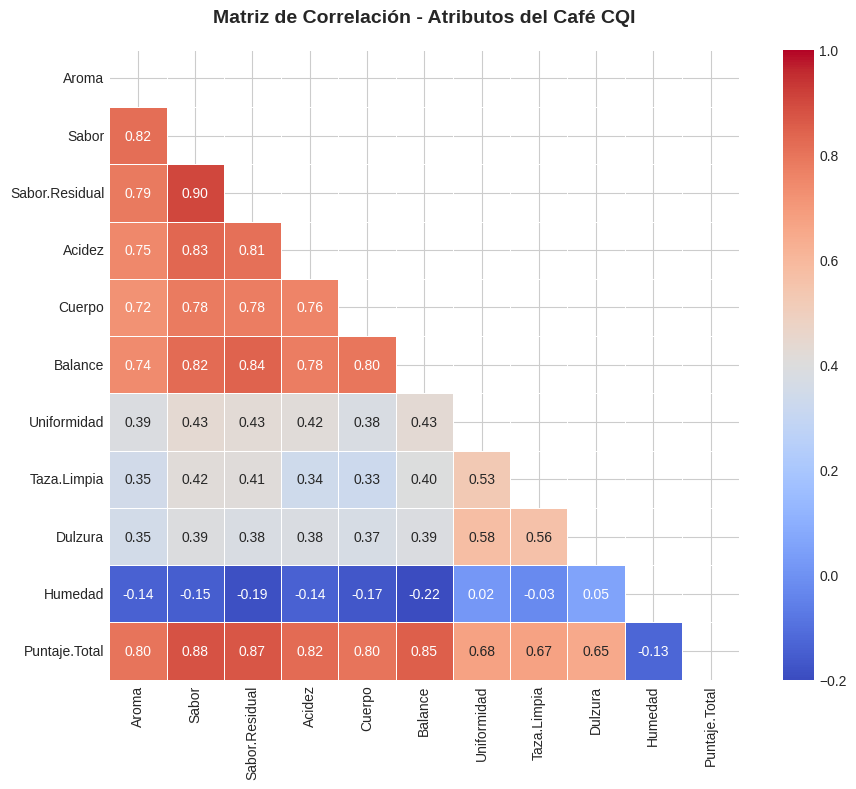

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ================================================================================
# 1. TRADUCCIÓN Y PREPROCESAMIENTO DE LAS CARACTERÍSTICAS
# ================================================================================

# Diccionario para mapear los nombres originales en inglés a español
mapa_traduccion = {
    "Aroma": "Aroma",
    "Flavor": "Sabor",
    "Aftertaste": "Sabor.Residual",
    "Acidity": "Acidez",
    "Body": "Cuerpo",
    "Balance": "Balance",
    "Uniformity": "Uniformidad",
    "Clean.Cup": "Taza.Limpia",
    "Sweetness": "Dulzura",
    "Moisture": "Humedad",
    "Total.Cup.Points": "Puntaje.Total",
}

# Primero estandarizamos los puntos del dataframe original (como en tu paso 1)
df.columns = [c.replace(" ", ".") for c in df.columns]

# Renombramos las columnas del DataFrame usando nuestro diccionario en español
df = df.rename(columns=mapa_traduccion)

# Definimos las nuevas listas de variables con los nombres en español
caracteristicas_num = [
    "Aroma",
    "Sabor",
    "Sabor.Residual",
    "Acidez",
    "Cuerpo",
    "Balance",
    "Uniformidad",
    "Taza.Limpia",
    "Dulzura",
    "Humedad",
]
objetivo = "Puntaje.Total"

# [El resto de tus pasos de imputación y división se mantienen igual pero con las nuevas variables]
for col in caracteristicas_num:
    df[col] = df[col].fillna(df[col].median())

X = df[caracteristicas_num]
y = df[objetivo]

# Nota: Asegúrate de volver a generar tus variables X_train, y_train, etc., con este cambio.
# Para este análisis individual usamos el nuevo X_train y y_train traducidos:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Unimos temporalmente para la correlación
df_analisis = X_train.copy()
df_analisis["Puntaje.Total"] = y_train

# ================================================================================
# 2. ANÁLISIS DE VARIANZA (Nombres en Español)
# ================================================================================
varianzas = X_train.var().sort_values()
print("==========================================================")
print(" 📊 VARIANZA DE CADA CARACTERÍSTICA (X_train)")
print("==========================================================")
for col, var in varianzas.items():
    print(f"{col:<15} : Varianza = {var:.5f}")
print("-" * 58)
print(
    "Nota: Variables con varianza cercana a 0 (ej. Dulzura, Taza.Limpia)"
)
print("aportan muy poca información porque casi siempre valen lo mismo.\n")

# ================================================================================
# 3. MATRIZ DE CORRELACIÓN DE PEARSON (Nombres en Español)
# ================================================================================
matriz_corr = df_analisis.corr()

print("==========================================================")
print(" 📈 CORRELACIÓN DE PEARSON CON EL TARGET (Puntaje.Total)")
print("==========================================================")
corr_target = matriz_corr["Puntaje.Total"].sort_values(ascending=False)
print(corr_target.to_string())
print("==========================================================\n")

# ================================================================================
# 4. GENERACIÓN DEL MAPA DE CALOR (HEATMAP - TOTALMENTE EN ESPAÑOL)
# ================================================================================
plt.figure(figsize=(10, 8))

# Máscara para ocultar la mitad superior y limpiar la visualización
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(
    matriz_corr,
    mask=mascara,
    cmap="coolwarm",
    vmax=1.0,
    vmin=-0.2,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
)

plt.title(
    "Matriz de Correlación - Atributos del Café CQI",
    fontsize=14,
    pad=20,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# **MÉTODO PCA**

             FASE DE EXTRACCIÓN DE CARACTERÍSTICAS: PCA ☕

[ANÁLISIS] Varianza explicada acumulada por componente:
  Componentes 1 a 1: 57.54% de la varianza
  Componentes 1 a 2: 72.01% de la varianza
  Componentes 1 a 3: 81.06% de la varianza
  Componentes 1 a 4: 85.80% de la varianza
  Componentes 1 a 5: 90.02% de la varianza
  Componentes 1 a 6: 92.95% de la varianza
  Componentes 1 a 7: 95.37% de la varianza
  Componentes 1 a 8: 97.47% de la varianza
  Componentes 1 a 9: 99.08% de la varianza
  Componentes 1 a 10: 100.00% de la varianza

[DECISIÓN] Se seleccionan 7 componentes principales (Retienen el 95.37% de la varianza).

--- TABLA DE DESEMPEÑO TRAS REDUCCIÓN DE DIMENSIÓN (PCA) ---
                                Variables Orig. Componentes Reducción % Test RMSE   Test R2 Tiempo (seg)
1. Regresión Lineal (SGD) + PCA              10           7       30.0%  0.224215  0.991959     0.002003
2. K-Nearest Neighbors + PCA                 10           7       30.0%  0.575759  0.946974

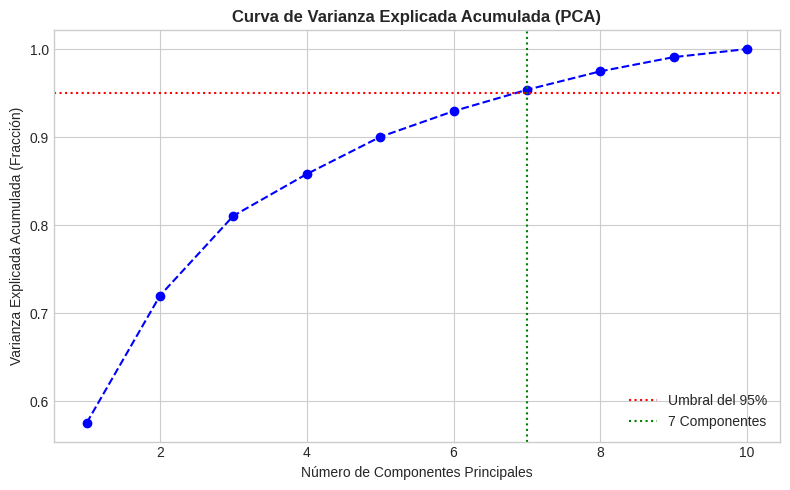

In [56]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("================================================================================")
print("             FASE DE EXTRACCIÓN DE CARACTERÍSTICAS: PCA ☕")
print("================================================================================")

# 1. Ajustar PCA con todos los componentes para evaluar la varianza
pca_completo = PCA(random_state=42)
pca_completo.fit(X_train_scaled)
varianza_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)

# Determinar el número óptimo de componentes para el 95% de varianza
n_componentes_optimo = np.argmax(varianza_acumulada >= 0.95) + 1

print(f"\n[ANÁLISIS] Varianza explicada acumulada por componente:")
for i, va in enumerate(varianza_acumulada):
    print(f"  Componentes 1 a {i+1}: {va*100:.2f}% de la varianza")

print(f"\n[DECISIÓN] Se seleccionan {n_componentes_optimo} componentes principales (Retienen el {varianza_acumulada[n_componentes_optimo-1]*100:.2f}% de la varianza).")

# 2. Aplicar la reducción de dimensión definitiva
pca = PCA(n_components=n_componentes_optimo, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Calcular porcentaje de reducción de características
n_original = X_train_scaled.shape[1]
porcentaje_reduccion = ((n_original - n_componentes_optimo) / n_original) * 100

# 3. Re-evaluación de los 2 mejores modelos
resultados_pca = {}

# --- MODELO 1: REGRESIÓN LINEAL (SGD) CON PCA ---
modelo_sgd_pca = SGDRegressor(loss='squared_error', learning_rate='constant', eta0=0.001, max_iter=1000, random_state=42)
inicio = time.time()
modelo_sgd_pca.fit(X_train_pca, y_train)
y_train_pred_sgd = modelo_sgd_pca.predict(X_train_pca)
y_test_pred_sgd = modelo_sgd_pca.predict(X_test_pca)
tiempo_sgd = time.time() - inicio

resultados_pca['1. Regresión Lineal (SGD) + PCA'] = {
    'Variables Orig.': n_original,
    'Componentes': n_componentes_optimo,
    'Reducción %': f"{porcentaje_reduccion:.1f}%",
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred_sgd)),
    'Test R2': r2_score(y_test, y_test_pred_sgd),
    'Tiempo (seg)': tiempo_sgd
}

# --- MODELO 2: K-NEAREST NEIGHBORS (KNN) CON PCA ---
modelo_knn_pca = KNeighborsRegressor(n_neighbors=5, weights='uniform', metric='minkowski', p=2)
inicio = time.time()
modelo_knn_pca.fit(X_train_pca, y_train)
y_train_pred_knn = modelo_knn_pca.predict(X_train_pca)
y_test_pred_knn = modelo_knn_pca.predict(X_test_pca)
tiempo_knn = time.time() - inicio

resultados_pca['2. K-Nearest Neighbors + PCA'] = {
    'Variables Orig.': n_original,
    'Componentes': n_componentes_optimo,
    'Reducción %': f"{porcentaje_reduccion:.1f}%",
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred_knn)),
    'Test R2': r2_score(y_test, y_test_pred_knn),
    'Tiempo (seg)': tiempo_knn
}

# 4. Mostrar Tabla de Desempeño con PCA
df_resultados_pca = pd.DataFrame(resultados_pca).T
print("\n--- TABLA DE DESEMPEÑO TRAS REDUCCIÓN DE DIMENSIÓN (PCA) ---")
print(df_resultados_pca.to_string())
print("================================================================================")

# 5. Graficar la curva de varianza explicada acumulada
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle=':', label='Umbral del 95%')
plt.axvline(x=n_componentes_optimo, color='g', linestyle=':', label=f'{n_componentes_optimo} Componentes')
plt.title('Curva de Varianza Explicada Acumulada (PCA)', fontsize=12, fontweight='bold')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada (Fracción)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# **MÉTODO UMAP**

In [57]:
import time
import numpy as np
import pandas as pd
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
import warnings
import umap

warnings.filterwarnings("ignore", message="n_jobs value.*overridden.*random_state")

print("================================================================================")
print("         FASE DE EXTRACCIÓN DE CARACTERÍSTICAS NO LINEAL: UMAP ☕")
print("================================================================================")

# 1. Configurar y aplicar UMAP
# n_components=3 según nuestro criterio de diseño
# n_neighbors controla el balance entre estructura local y global
# min_dist controla qué tan cerca pueden agruparse los puntos
reductor_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=42)

print("[PROCESANDO] Ajustando UMAP y transformando los conjuntos de datos...")
inicio_umap = time.time()
X_train_umap = reductor_umap.fit_transform(X_train_scaled)
X_test_umap = reductor_umap.transform(X_test_scaled)
tiempo_transformacion = time.time() - inicio_umap
print(f"[OK] Transformación completada en {tiempo_transformacion:.4f} segundos.")

# Calcular porcentaje de reducción de características
n_original = X_train_scaled.shape[1]
n_componentes_umap = 3
porcentaje_reduccion = ((n_original - n_componentes_umap) / n_original) * 100

# 2. Re-evaluación de los 2 mejores modelos sobre el espacio UMAP
resultados_umap = {}

# --- MODELO 1: REGRESIÓN LINEAL (SGD) CON UMAP ---
# Nota: Como UMAP deforma el espacio de manera no lineal, las relaciones lineales originales cambian.
modelo_sgd_umap = SGDRegressor(loss='squared_error', learning_rate='constant', eta0=0.001, max_iter=1000, random_state=42)
inicio = time.time()
modelo_sgd_umap.fit(X_train_umap, y_train)
y_test_pred_sgd = modelo_sgd_umap.predict(X_test_umap)
tiempo_sgd = time.time() - inicio

resultados_umap['1. Regresión Lineal (SGD) + UMAP'] = {
    'Variables Orig.': n_original,
    'Componentes': n_componentes_umap,
    'Reducción %': f"{porcentaje_reduccion:.1f}%",
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred_sgd)),
    'Test R2': r2_score(y_test, y_test_pred_sgd),
    'Tiempo (seg)': tiempo_sgd
}

# --- MODELO 2: K-NEAREST NEIGHBORS (KNN) CON UMAP ---
# Nota: KNN suele emparejarse muy bien con UMAP ya que ambos basan su lógica en vecindades locales.
modelo_knn_umap = KNeighborsRegressor(n_neighbors=5, weights='uniform', metric='minkowski', p=2)
inicio = time.time()
modelo_knn_umap.fit(X_train_umap, y_train)
y_test_pred_knn = modelo_knn_umap.predict(X_test_umap)
tiempo_knn = time.time() - inicio

resultados_umap['2. K-Nearest Neighbors + UMAP'] = {
    'Variables Orig.': n_original,
    'Componentes': n_componentes_umap,
    'Reducción %': f"{porcentaje_reduccion:.1f}%",
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred_knn)),
    'Test R2': r2_score(y_test, y_test_pred_knn),
    'Tiempo (seg)': tiempo_knn
}

# 3. Mostrar Tabla de Desempeño con UMAP
df_resultados_umap = pd.DataFrame(resultados_umap).T
print("\n--- TABLA DE DESEMPEÑO TRAS REDUCCIÓN NO LINEAL (UMAP) ---")
print(df_resultados_umap.to_string())
print("================================================================================")

         FASE DE EXTRACCIÓN DE CARACTERÍSTICAS NO LINEAL: UMAP ☕
[PROCESANDO] Ajustando UMAP y transformando los conjuntos de datos...
[OK] Transformación completada en 2.2858 segundos.

--- TABLA DE DESEMPEÑO TRAS REDUCCIÓN NO LINEAL (UMAP) ---
                                 Variables Orig. Componentes Reducción % Test RMSE   Test R2 Tiempo (seg)
1. Regresión Lineal (SGD) + UMAP              10           3       70.0%  2.570795 -0.057159     0.009738
2. K-Nearest Neighbors + UMAP                 10           3       70.0%  1.047171  0.824596     0.001936
